[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Download Github files

In [ ]:
try:
    import google.colab
    %mkdir data
    %mkdir scripts
    %mkdir results
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/data/INA_dataset.json -O data/INA_dataset.json
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/models.py -O scripts/models.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/utils.py -O scripts/utils.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/embedding.py -O scripts/embedding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/cv_folding.py -O scripts/cv_folding.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/configure.py -O scripts/configure.py
    !wget -np https://raw.githubusercontent.com/giordamaug/Relational_EHR_data_to_Longitudinal_Patient_Trajectories/main/scripts/plotting.py -O scripts/plotting.py
    print("Working on Colab!")
except:
    raise Exception("cannot dwnload Githb files!")

## Load dataset

In [ ]:
import sys
sys.path.append('.')
from scripts.utils import Settings

DATA_PATH = "data" # "your-path-to-data"
dataset = "INA"
if dataset == "INA":
    datafile =  "INA_dataset.json"
    target_var = "is_alive?"
    evfields = ['code_descr']
    static_vars = ["gender", "age_group", "base_pathology_area"]
    remove_events = ['followup', 'platelet_change', 'bmi_change', 'thrombosys']
    no_selection = False
    thresh = 0.3
elif dataset == "MIMIC":
    datafile = "mimic-iv_asplenic.json"
    static_vars = ["gender", "age_at_splenectomy", "base_pathology_area"]
    target_var = "is_alive?"
    evfields = ['event']
    remove_events = ['drug']
    no_selection = True
    thresh = 0.3
else:
    raise Exception("dataset not supported!")
args = Settings(datafile = os.path.join(DATA_PATH, datafile), 
                no_selection=no_selection,
                pathology_field = 'base_pathology_area', #'base_pathology_area', # 'primarys_disease'
                static_vars= static_vars,
                target_var = target_var,
                pathologies={'Asplenic Syndromes' : 'AS', 
                            'Autoimmune Hematological Diseases' : 'AIHD', 
                            'Congenital Hemolytic Anemias' : 'CHA', 
                            'Immunodeficiencies' : 'IM', 
                            'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)' : 'NTDT', 
                            'Non-Hemato-Oncological Causes' : 'NHOC', 
                            'Oncological Diseases' : 'OD', 
                            'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)' : 'SCD', 
                            'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)' : 'TDT'},
                spleen_flags = ['YES', 'NO'],
                selected_spleen_flags = ['YES'],
                methods=['LSTM', 'GRU', 'GRU-D', 'BEHRT', 'Dipole', 'DOME', 'BINARY'],
                evfields = evfields,
                remove_events = remove_events,
                enable_plot=True, 
                n_splits=5, 
                num_epochs=10, 
                batch_size = 16, 
                embedding_size=128,
                hidden_size=300)
args.iterated_cv = True
args.iter = 5
args.results_dir = "results"
%mkdir args.results_dir

Loaded 1492 records from data/dataset_14_04_26_EN.json


### Remove patients with specific cause of death

In [3]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide", "fracture", "malignant", "myeloma"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 1487


### Remove patients with no events

In [4]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 1486


## Plot patients distribution

Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


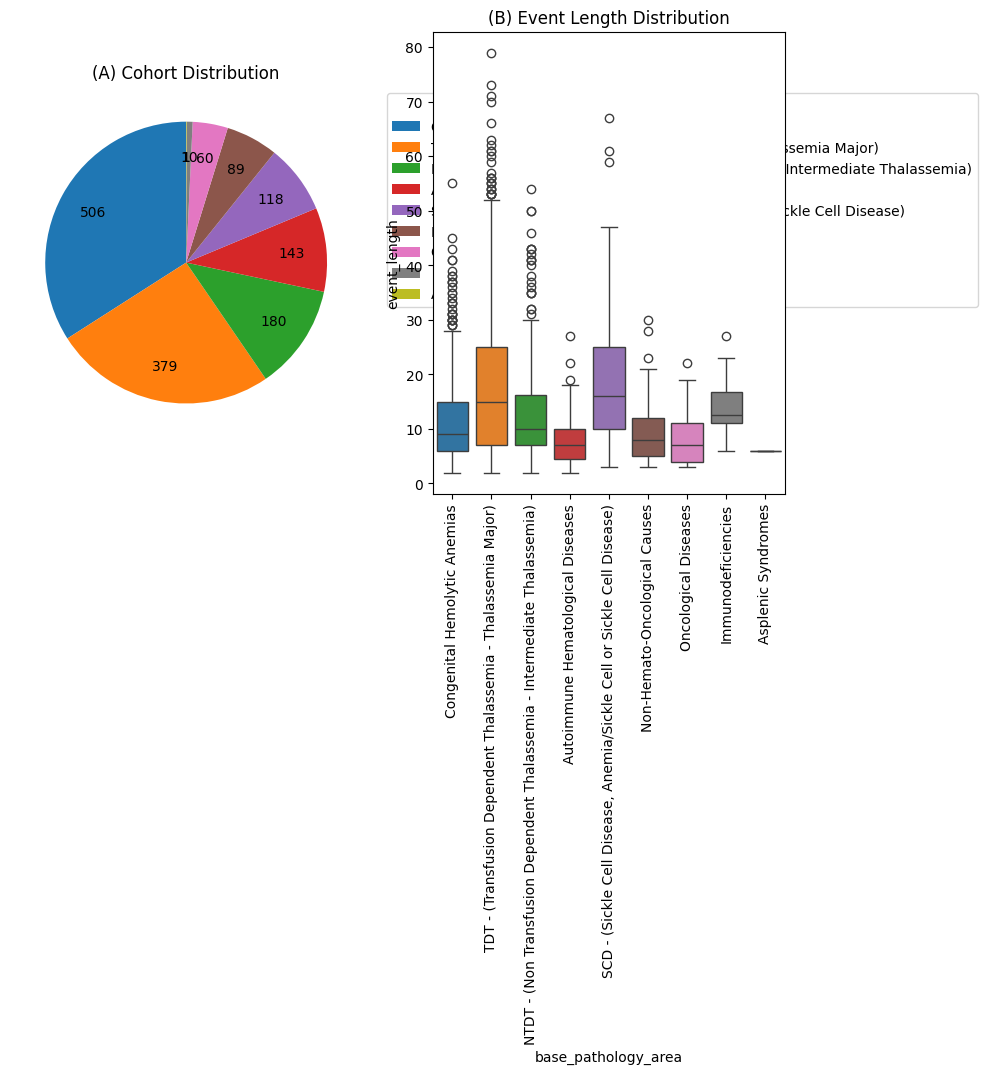

In [5]:
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

## Get clinical trajectories

In [6]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), 
    event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 

### Remove events by types

n.1486 Patients
Index(['Congenital Hemolytic Anemias',
       'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)',
       'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)',
       'Autoimmune Hematological Diseases',
       'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)',
       'Non-Hemato-Oncological Causes', 'Oncological Diseases',
       'Immunodeficiencies', 'Asplenic Syndromes'],
      dtype='object', name='base_pathology_area')


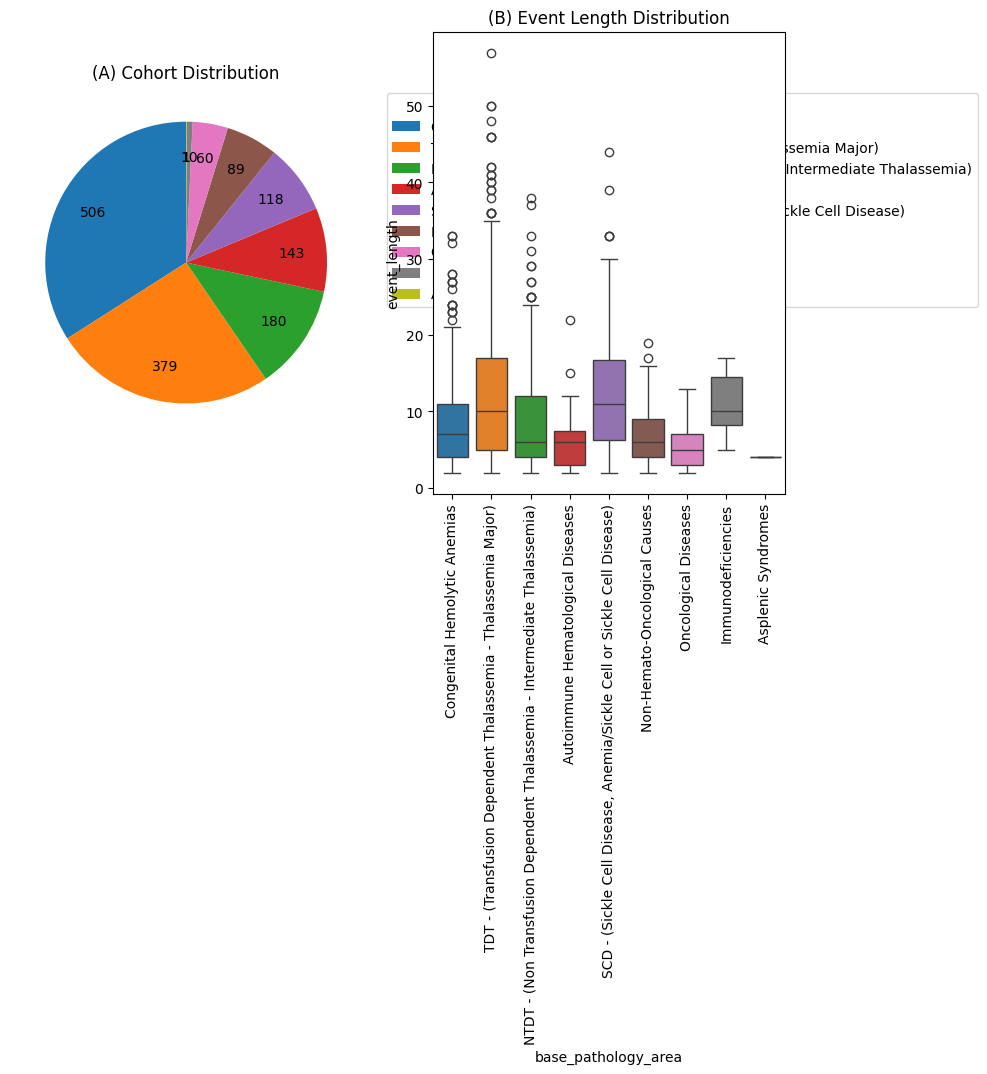

In [7]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
event_sequences_type = { id: [(" ".join([event[field] if isinstance(event[field], str) else "NONE" for field in args.evfields]), event[date_field], event[type_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")
if "base_pathology_area" in args.dataset.columns:
    from scripts.utils import plot_group_distribution_with_event_boxplot
    plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

In [8]:
event_sequences = { id: events for (id,events) in event_sequences.items() if len(events) > 0 } 
event_sequences_type = { id: events for (id,events) in event_sequences_type.items() if len(events) > 0 }
args.selected_patient_ids = np.array(list(event_sequences.keys()))

### count event by type and cardinality

In [10]:
count_events_by_type(event_sequences_type)

,cardinality,n. instances,set
type,,,
surgical_operation,14,1561,"{NONE, Resection of spleen, open approach, Tra..."
therapy,39,4998,"{Introduction of sickle-cell therapy agent, In..."
vaccination,9,6548,"{Haemophilus influenzae type b vaccine, PRP-T ..."
infection,71,555,"{Enteritis unspecified, COVID-19, Urinary trac..."
comorbidity,241,830,"{Leukemia, unspecified; Leukemia of unspecifie..."


## Get static variables

In [11]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,base_pathology_area
id,,,
1,0,0,0
2,1,0,1
3,0,0,1
4,1,0,1
5,0,0,2
...,...,...,...
1948,1,0,1
1949,1,0,1
1950,1,2,1


## Get targets

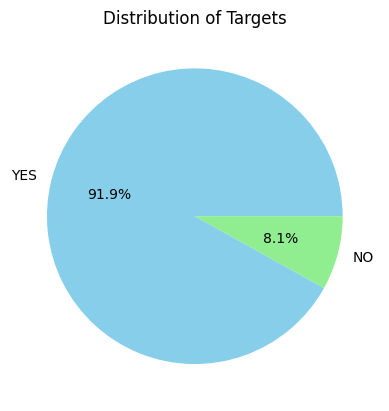

In [12]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(f"data/{dataset}_targets.csv")
plt.show()

In [13]:
target_df.value_counts(dropna=False)

is_alive?
0    1366
1     120
Name: count, dtype: int64

In [14]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, event_sequences_type, target_df.to_dict(), X_static, args)

#Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string", "Brier": "float64"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

## Validation (Iterated 5-fold)

In [18]:
import pickle
if args.iterated_cv:
    from scripts.cv_folding import lgbm_cv_iter
    metrics = ["AUC","F1","Prec","Recall","MCC","Acc","Brier","CM"]
    args.methods = [['STATIC'],
                    ['STATIC', 'EVENT-CNT'], 
                    ['STATIC', 'BiPadLSTM'], 
                    ['STATIC', 'Med2Vec'],
                    ['STATIC', 'Dipole'],
                    ['STATIC', 'CEHR-BERT'],
                    ['STATIC', 'DOME'],
                    ['STATIC', 'GRU'],
                    ]
    prob_pred = {"+".join(m): [] for m in args.methods}
    prob_true = {"+".join(m): [] for m in args.methods}
    all_runs = {"+".join(m): ([], []) for m in args.methods}
    res = {metric: {"+".join(m): [] for m in args.methods} for metric in metrics}
    for i in range(args.iter):
        for m in args.methods:
            set_seed(args.random_state+i)
            results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                                methods=m, threshold=thresh, random_state=args.random_state+i, 
                                                                return_metrics=True)
            prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
            prob_true["+".join(m)] += list(results['calibration_prob_true'])
            all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                     all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
            with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER{args.iter}.pkl", 'wb') as f:
                pickle.dump(results, f)
            for metric in res.keys():
                print("+".join(m), metric)
                res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
            results_df = pd.concat([results_df, results_tmp],axis=0)
    for metric in res.keys():
        pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER{args.iter}.csv")
    results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER{args.iter}.csv")
    results_df


STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


## Validation (5-fold)

In [19]:
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols)
for m in args.methods:
    set_seed(args.random_state)
    results_tmp, model, _,_,_,_, results = lgbm_cv_iter(embedder_configs, target_df, args.selected_patient_ids, 
                                                        methods=m, threshold=thresh, random_state=args.random_state, 
                                                        return_metrics=True)
    prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
    prob_true["+".join(m)] += list(results['calibration_prob_true'])
    all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
    with open(f"{args.results_dir}/results_{dataset}_{'_'.join(m)}_ITER1.pkl", 'wb') as f:
        pickle.dump(results, f)
    for metric in res.keys():
        print("+".join(m), metric)
        res[metric]["+".join(m)] += [results[metric].tolist()] if metric == "CM" else [results[metric]] if metric == "Brier" else results[metric]
    results_df = pd.concat([results_df, results_tmp],axis=0)
for metric in res.keys():
    pd.DataFrame(res[metric]).to_csv(f"{args.results_dir}/resdata_{metric}_{dataset}_ITER1.csv")
results_df.to_csv(f"{args.results_dir}/results_{dataset}_ITER1.csv")
results_df


STATIC+GRU AUC
STATIC+GRU F1
STATIC+GRU Prec
STATIC+GRU Recall
STATIC+GRU MCC
STATIC+GRU Acc
STATIC+GRU Brier
STATIC+GRU CM


,AUC mean,AUC std,F1 mean,F1 std,Prec mean,Prec std,Recall mean,Recall std,MCC mean,MCC std,Acc mean,Acc std,CM,Brier
STATIC,0.532552,0.083994,0.126343,0.067453,0.070822,0.038230,0.600000,0.308386,0.022304,0.075658,0.457846,0.253291,"[[357, 445], [28, 42]]",0.144729
STATIC+EVENT-CNT,0.780281,0.027636,0.294520,0.048920,0.199225,0.037720,0.571429,0.078246,0.237658,0.063321,0.777550,0.029801,"[[638, 164], [30, 40]]",0.088149
STATIC+BiPadLSTM,0.780262,0.092449,0.519271,0.032485,0.475699,0.032635,0.585714,0.104978,0.479470,0.040954,0.913997,0.006204,"[[756, 46], [29, 41]]",0.059874
STATIC+Med2Vec,0.759257,0.110755,0.339654,0.199162,0.440606,0.154820,0.300000,0.208982,0.316026,0.189725,0.919718,0.011539,"[[781, 21], [49, 21]]",0.066666
STATIC+Dipole,0.743498,0.079458,0.471522,0.089922,0.553922,0.117973,0.428571,0.101015,0.441601,0.091871,0.923159,0.017677,"[[775, 27], [40, 30]]",0.062517
STATIC+CEHR-BERT,0.800960,0.086781,0.411863,0.142549,0.401634,0.176236,0.428571,0.110657,0.358171,0.158454,0.897984,0.028735,"[[753, 49], [40, 30]]",0.069717
STATIC+DOME,0.937081,0.046178,0.594694,0.070298,0.490735,0.084625,0.771429,0.083299,0.570675,0.073975,0.914036,0.021276,"[[743, 59], [16, 54]]",0.047038
STATIC+GRU,0.662768,0.093489,0.247387,0.102566,0.634387,0.313571,0.214286,0.127775,0.271924,0.052631,0.905931,0.030837,"[[775, 27], [55, 15]]",0.069914


## Plot calibaration curves

In [ ]:
from scripts.plotting import plot_calibration
fig = plot_calibration(prob_pred, prob_true,all_runs,title=f"Calibration curves ({dataset})")